In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scipy.stats
from scipy.special import logit, expit
import matplotlib.pyplot as plt

import sys
sys.path.append('../../python/example/berry')
import util

sigma2_n = 90
n_arms = 2
mu_sig_sq = 100.0
mu_0 = -1.34
logit_p1 = logit(0.3)
n = np.full((1, 2), 35)
y = np.array([[2, 8]])
n.shape, y.shape

((1, 2), (1, 2))

In [3]:
sigma2_n = sigma2_n
sigma2_rule = util.log_gauss_rule(sigma2_n, 1e-6, 1e3)
arms = np.arange(n_arms)
cov = np.full((sigma2_n, n_arms, n_arms), mu_sig_sq)
cov[:, arms, arms] += sigma2_rule.pts[:, None]
neg_precQ = -np.linalg.inv(cov)
logprecQdet = 0.5 * np.log(np.linalg.det(-neg_precQ))
log_prior = scipy.stats.invgamma.logpdf(
    sigma2_rule.pts, 0.0005, scale=0.000005
)

In [4]:
def calc_log_joint(theta, sig_idx):
    theta_m0 = theta - mu_0
    theta_adj = theta + logit_p1
    exp_theta_adj = np.exp(theta_adj)
    out = (
        0.5 * np.einsum("...i,...ij,...j", theta_m0, neg_precQ[sig_idx], theta_m0)
        + np.sum(
            theta_adj * y - n * np.log(exp_theta_adj + 1),
            axis=-1,
        )
    )
    out -= np.max(out)
    return out

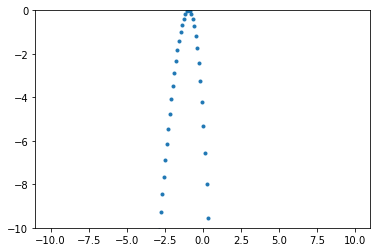

In [5]:
ts = np.linspace(-10, 10, 200)
theta2d = np.meshgrid(ts, ts, indexing = 'ij')
theta = np.stack([ti.ravel() for ti in theta2d], axis=-1)
theta1d = np.stack((theta2d[0][:,0], theta2d[0][:,0]),axis=-1)
theta1d[:,1] = theta1d[:,0]
theta = theta1d
sig_idx = 0
logjoint = calc_log_joint(theta, sig_idx)
logjoint -= logjoint.max()
levels = np.linspace(-10, 0, 21)
plt.plot(theta1d[:,0], logjoint, '.')
plt.ylim([-10, 0])
plt.show()

In [6]:
import berry
import inla
import quadrature
import fast_inla

fi = fast_inla.FastINLA(n_arms, sigma2_n=sigma2_n)
n_theta = 11
w_theta = 10
integrate_sigma = False

/Users/tbent/.mambaforge/envs/kevlar/lib/python3.10/site-packages/jax/_src/lib/__init__.py:33: UserWarning: JAX on Mac ARM machines is experimental and minimally tested. Please see https://github.com/google/jax/issues/5501 in the event of problems.
  warnings.warn("JAX on Mac ARM machines is experimental and minimally tested. "


/Users/tbent/.mambaforge/envs/kevlar/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


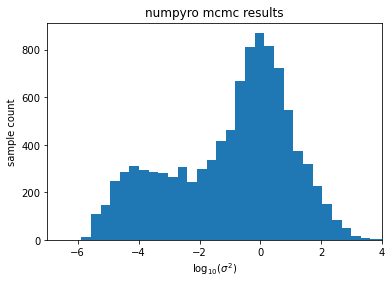

In [7]:
import mcmc

results_mcmc = mcmc.mcmc_berry(
    np.stack((y,n), axis=-1),
    fi.logit_p1,
    np.full(y.shape[0], fi.thresh_theta),
    n_arms=n_arms,
    dtype=np.float64,
    n_samples=10000
)

sigma2_mcmc = results_mcmc["x"][0]["sigma2"][0]
plt.title("numpyro mcmc results")
plt.hist(np.log10(sigma2_mcmc.to_py()), bins=40)
plt.xlabel("$\log_{10} (\sigma^2)$")
plt.ylabel("sample count")
plt.xlim([-7, 4])
plt.show()

mcmc_cdf = (sigma2_mcmc[None, :] < fi.sigma2_rule.pts[:, None]).sum(axis=1)
mcmc_pdf = np.zeros(fi.sigma2_rule.pts.shape[0])
mcmc_pdf[1:] = (mcmc_cdf[1:] - mcmc_cdf[:-1]) / sigma2_mcmc.shape[0]

In [9]:
points, weights = np.polynomial.legendre.leggauss(n_theta)
etapts = w_theta * points
etawts = w_theta * weights
grid_eta = np.stack(
    np.meshgrid(*[etapts for k in range(fi.n_arms)], indexing="ij"), axis=-1
)
grid_eta_wts = np.prod(
    np.stack(
        np.meshgrid(*[etawts for k in range(fi.n_arms)], indexing="ij"), axis=-1
    ),
    axis=-1,
)

phat = y / n
sample_I = n * phat * (1 - phat)

# TODO: we can also use inla hess_inv to compute the full variance here with
# higher fidelity than DB.
sigma2_post_fi, _, mode, _, hess_inv = fi.numpy_inference(y, n)
sigma_posterior = -hess_inv  # np.transpose(hess_inv, (0, 1, 3, 2))

# Dirty bayes calculation of variance matrix.
sigma_precision = np.empty((sample_I.shape[0], *fi.neg_precQ.shape))
sigma_precision[:] = fi.neg_precQ[None, ...]
sigma_precision[..., fi.arms, fi.arms] += sample_I[:, None, ...]
sigma_posterior2 = np.linalg.inv(sigma_precision)

# Step : decorrelate our coordinate system.
w, v = np.linalg.eigh(sigma_posterior)
# axis_half_len = w
axis_half_len = np.sqrt(np.abs(w))

# Map from eta to theta space.
broadcast_shape = list(mode.shape)
for i in range(fi.n_arms):
    broadcast_shape.insert(1, 1)
grid_theta = np.einsum(
    "klij,...i,kli->k...lj", v, grid_eta, axis_half_len
) + mode.reshape(broadcast_shape)

# We need to multiply by the absolute value of the determinant of the
# transformation. Because we have already computed a eigendecomposition, the
# determinant of matrix is just product of eigenvalues.
det_jacobian = axis_half_len.prod(axis=-1)
grid_theta_wts = np.einsum("kl,ij->kijl", det_jacobian, grid_eta_wts)

sigma2_broadcast = [1] * len(grid_theta_wts.shape)
sigma2_broadcast[-1] = fi.sigma2_rule.wts.shape[0]
full_grid = np.empty((*grid_theta_wts.shape, fi.n_arms + 1))
full_grid[..., :2] = grid_theta
full_grid[..., 2] = fi.sigma2_rule.pts.reshape(sigma2_broadcast)

full_wts = grid_theta_wts
if integrate_sigma:
    full_wts *= fi.sigma2_rule.wts.reshape(sigma2_broadcast)

10


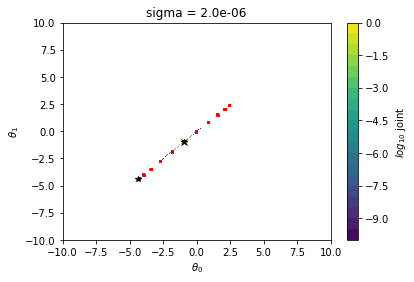

In [10]:
ts = np.linspace(-10, 10, 200)
theta2d = np.meshgrid(ts, ts, indexing = 'ij')
theta = np.stack([ti.ravel() for ti in theta2d], axis=-1)
for sig_idx in [10]:#range(0, sigma2_n, 1):
    print(sig_idx)
    logjoint = calc_log_joint(theta, sig_idx)

    levels = np.linspace(-10, 0, 21)
    plt.contourf(theta2d[0], theta2d[1], logjoint.reshape(theta2d[0].shape), levels=levels)
    plt.plot(*mode[0,sig_idx], 'kx')

    # plt.plot(new_pts[0, :, :, sig_idx,0].ravel(), new_pts[0, :,:,sig_idx,1].ravel(), 'ko', markersize=8)
    plt.plot(grid_theta[0, :,:, sig_idx, 0].ravel(), grid_theta[0, :,:, sig_idx, 1].ravel(), 'ro', markersize=2)

    plt.plot(*(mode[0,sig_idx] + axis_half_len[0,sig_idx,0] * w_theta * v[0,sig_idx,0]), 'k*')
    plt.plot(*(mode[0,sig_idx] + axis_half_len[0,sig_idx,1] * w_theta * v[0,sig_idx,1]), 'k*')
    plt.xlabel(r'$\theta_0$')
    plt.ylabel(r'$\theta_1$')

    plt.title(f'sigma = {sigma2_rule.pts[sig_idx]:.1e}')
    cbar = plt.colorbar()
    cbar.set_label('$log_{10}$ joint')
    plt.xlim([ts.min(), ts.max()])
    plt.ylim([ts.min(), ts.max()])
    plt.show()

In [11]:
grid_eta.shape

(11, 11, 2)

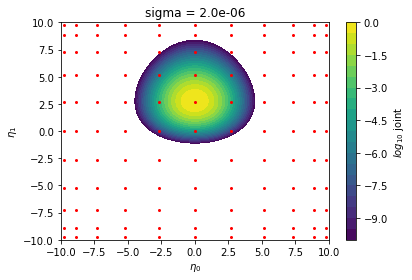

In [12]:
sig_idx = 10
eta = np.stack([ti.ravel() for ti in theta2d], axis=-1)
theta = (eta * axis_half_len[0,sig_idx]).dot(v[0,sig_idx])
logjoint = calc_log_joint(theta, sig_idx)

levels = np.linspace(-10, 0, 21)
plt.contourf(theta2d[0], theta2d[1], logjoint.reshape(theta2d[0].shape), levels=levels)

plt.plot(grid_eta[:,:,0].ravel(), grid_eta[:,:,1].ravel(), 'ro', markersize=2)
plt.xlabel(r'$\eta_0$')
plt.ylabel(r'$\eta_1$')

plt.title(f'sigma = {sigma2_rule.pts[sig_idx]:.1e}')
cbar = plt.colorbar()
cbar.set_label('$log_{10}$ joint')
plt.xlim([ts.min(), ts.max()])
plt.ylim([ts.min(), ts.max()])
plt.show()

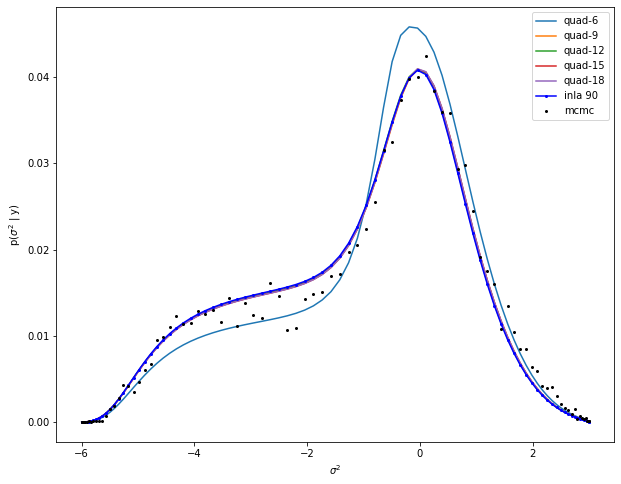

In [15]:
plt.figure(figsize=(10,8))
for nq in [6, 9, 12, 15, 18]:
    full_grid, full_wts = quadrature.build_grid(
        fi, y, n, integrate_sigma2=False, n_theta=nq, w_theta=w_theta
    )
    pr = full_grid[...,:2].reshape((-1, fi.sigma2_n, fi.n_arms))
    log_joint = fi.log_joint(y, n, pr).reshape(full_grid.shape[:-1])
    integral = (np.exp(log_joint) * full_wts).sum(axis=(1,2))
    denom = (integral * fi.sigma2_rule.wts).sum()
    integral[0] /= denom
    plt.plot(np.log10(fi.sigma2_rule.pts), integral[0] * fi.sigma2_rule.wts, label = f'quad-{nq}')
plt.plot(np.log10(fi.sigma2_rule.pts), sigma2_post_fi[0] * fi.sigma2_rule.wts, 'b-o', markersize=2, label='inla 90')
plt.plot(np.log10(fi.sigma2_rule.pts), mcmc_pdf, 'ko', markersize=2, label='mcmc')
plt.legend()
plt.xlabel('$\sigma^2$')
plt.ylabel('p($\sigma^2$ | y)')
plt.show()

/var/folders/mt/cmys2v_143q1kpcrdt5wcdyr0000gn/T/ipykernel_74065/335717603.py:13: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(fi.sigma2_rule.pts), np.log10(mcmc_pdf / fi.sigma2_rule.wts), 'mo', markersize=2, label='mcmc')


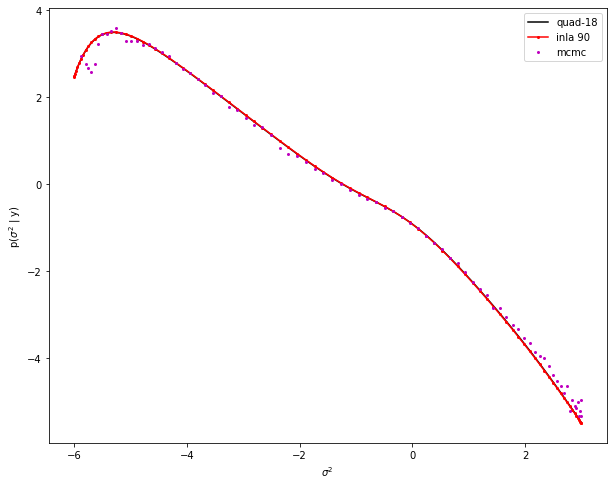

In [18]:
plt.figure(figsize=(10,8))
for nq in [18]:
    full_grid, full_wts = quadrature.build_grid(
        fi, y, n, integrate_sigma2=False, n_theta=nq, w_theta=w_theta
    )
    pr = full_grid[...,:2].reshape((-1, fi.sigma2_n, fi.n_arms))
    log_joint = fi.log_joint(y, n, pr).reshape(full_grid.shape[:-1])
    integral = (np.exp(log_joint) * full_wts).sum(axis=(1,2))
    denom = (integral * fi.sigma2_rule.wts).sum()
    integral[0] /= denom
    plt.plot(np.log10(fi.sigma2_rule.pts), np.log10(integral[0]), 'k-', label = f'quad-{nq}')
plt.plot(np.log10(fi.sigma2_rule.pts), np.log10(sigma2_post_fi[0]), 'r-o', markersize=2, label='inla 90')
plt.plot(np.log10(fi.sigma2_rule.pts), np.log10(mcmc_pdf / fi.sigma2_rule.wts), 'mo', markersize=2, label='mcmc')
plt.legend()
plt.xlabel('$\sigma^2$')
plt.ylabel('p($\sigma^2$ | y)')
plt.show()